In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted!")

Mounted at /content/drive
✓ Google Drive mounted!


# 📊 Telco Customer Churn – Data Cleaning & Preparation Lab

This notebook focuses on cleaning and preparing the Telco Customer Churn dataset for machine learning.

The dataset contains customer demographics, service usage, account information, and a target variable indicating whether a customer has churned or not.

## 🎯 Learning Objectives

- Load and explore dataset structure  
- Handle missing values and data quality issues  
- Clean categorical and numerical features  
- Detect and remove duplicates  
- Convert data into ML-ready format  
- Prepare dataset for EDA and modeling  

In [3]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

## 📌 Dataset Overview

The Telco Customer Churn dataset includes:

- Demographics: gender, senior citizen, partner, dependents  
- Services: internet, phone, streaming services  
- Account info: tenure, monthly charges, total charges  
- Target variable: **Churn (Yes/No)**  

This is a **binary classification problem** where we predict customer churn.

In [8]:
# ============================================================
# STEP 1: LOAD DATA
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/ML/Customer Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# ============================================================
# STEP 2: BASIC INSPECTION
# ============================================================
print(df.info())
print(df.head())

# ============================================================
# STEP 3: CLEAN COLUMN NAMES + STRIP STRINGS
# ============================================================
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## ❓ Missing Values Handling

We check for missing values and handle them appropriately.

In [9]:
# ============================================================
# STEP 4: CONVERT TOTALCHARGES TO NUMERIC
# ============================================================
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing after conversion
print(df["TotalCharges"].isnull().sum())

# Impute missing with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

11


## 🔁 Duplicates Check

We ensure there are no duplicate records in the dataset.

In [10]:
# ============================================================
# STEP 5: CHECK DUPLICATES (FULL ROW + ID)
# ============================================================
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate customerID:", df["customerID"].duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()

Duplicate rows: 0
Duplicate customerID: 0


In [11]:
# ============================================================
# STEP 6: DROP CUSTOMER ID (IMPORTANT)
# ============================================================
df = df.drop("customerID", axis=1)

## 🎯 Feature and Target Separation

We separate input features and target variable.

In [12]:
# ============================================================
# STEP 7: TARGET VARIABLE ENCODING
# ============================================================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Churn"] = le.fit_transform(df["Churn"])   # Yes=1, No=0

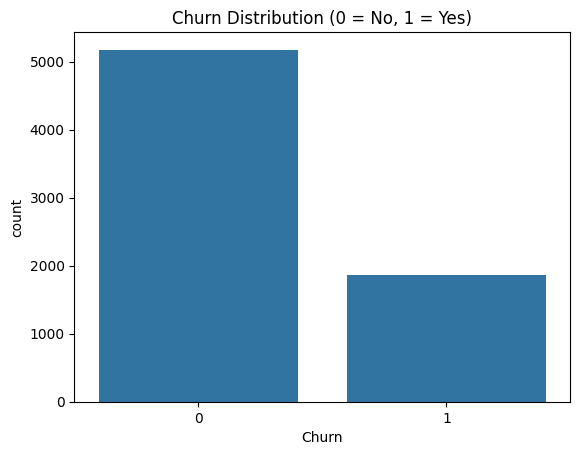

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Class Imbalance Ratio: 0.3612292230382683

⚠️ Class imbalance detected.
👉 We will use STRATIFIED SAMPLING in train-test split to maintain class proportion.


In [14]:
# ============================================================
# STEP 8: CHECK CLASS DISTRIBUTION
# ============================================================

sns.countplot(x=df["Churn"])
plt.title("Churn Distribution (0 = No, 1 = Yes)")
plt.show()

# Percentage distribution
class_dist = df["Churn"].value_counts(normalize=True)
print(class_dist)

# ============================================================
# STEP 8.1: CLASS IMBALANCE CHECK
# ============================================================

imbalance_ratio = class_dist.min() / class_dist.max()

print("\nClass Imbalance Ratio:", imbalance_ratio)

if imbalance_ratio < 0.5:
    print("\n⚠️ Class imbalance detected.")
    print("👉 We will use STRATIFIED SAMPLING in train-test split to maintain class proportion.")
else:
    print("\n✅ Dataset is balanced.")

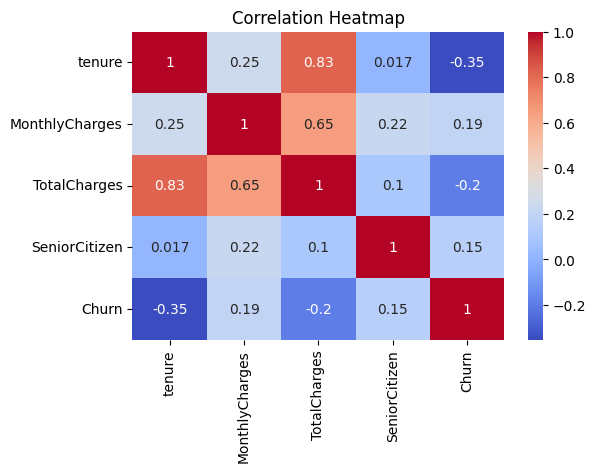

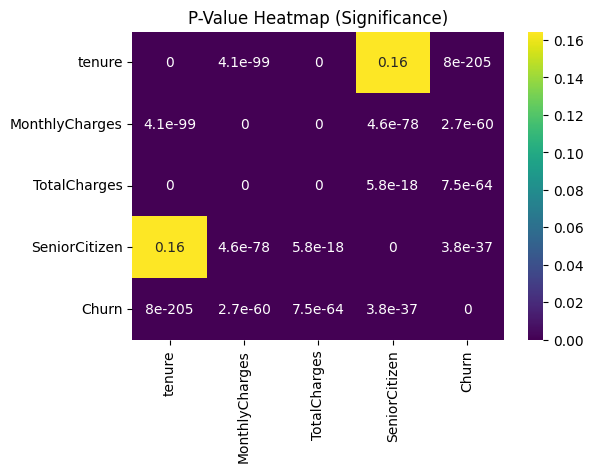

                Correlation        P-Value
Churn              1.000000   0.000000e+00
MonthlyCharges     0.193356   2.706646e-60
SeniorCitizen      0.150889   3.839860e-37
TotalCharges      -0.199037   7.508609e-64
tenure            -0.352229  7.999058e-205


In [23]:
# ============================================================
# STEP 9: CORRELATION + P-VALUE (NUMERIC FEATURES ONLY)
# ============================================================

from scipy.stats import pearsonr
import numpy as np

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

# Correlation matrix
corr = df[num_cols + ["Churn"]].corr()

# ============================================================
# P-VALUE MATRIX
# ============================================================

p_values = pd.DataFrame(np.ones_like(corr),
                        columns=corr.columns,
                        index=corr.index)

for col1 in corr.columns:
    for col2 in corr.columns:
        if col1 == col2:
            p_values.loc[col1, col2] = 0
        else:
            _, p = pearsonr(df[col1], df[col2])
            p_values.loc[col1, col2] = p

# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# P-VALUE HEATMAP
# ============================================================

plt.figure(figsize=(6,4))
sns.heatmap(p_values, annot=True, cmap="viridis")
plt.title("P-Value Heatmap (Significance)")
plt.show()

# ============================================================
# SIGNIFICANT RELATIONSHIP WITH TARGET (Churn)
# ============================================================

result = pd.DataFrame({
    "Correlation": corr["Churn"],
    "P-Value": p_values["Churn"]
}).sort_values(by="Correlation", ascending=False)

print(result)

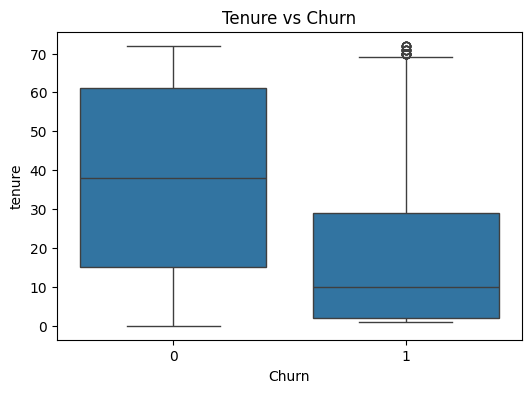

In [16]:
# ============================================================
# STEP 10: TENURE VS CHURN INSIGHT
# ============================================================
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Churn"], y=df["tenure"])
plt.title("Tenure vs Churn")
plt.show()

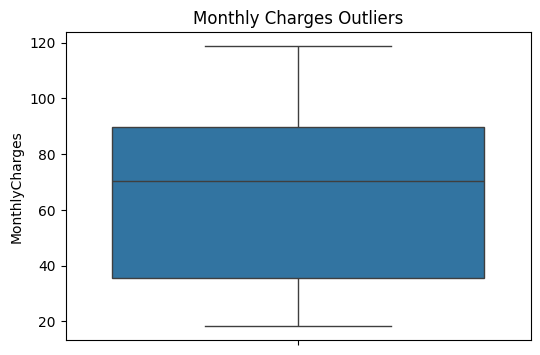

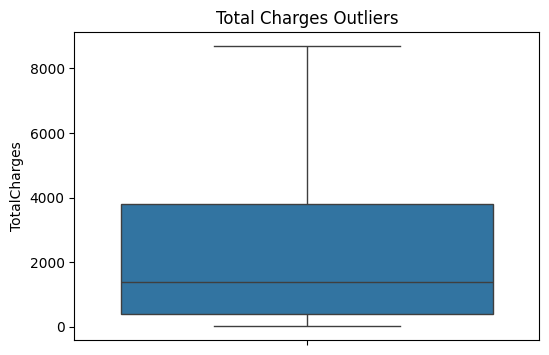

In [17]:
# ============================================================
# STEP 11: OUTLIER CHECK (MONTHLY & TOTAL CHARGES)
# ============================================================
plt.figure(figsize=(6,4))
sns.boxplot(y=df["MonthlyCharges"])
plt.title("Monthly Charges Outliers")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y=df["TotalCharges"])
plt.title("Total Charges Outliers")
plt.show()

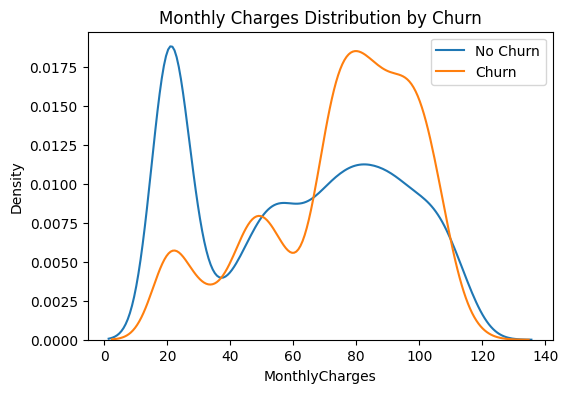

In [20]:
#Monthly Charges vs Churn (Distribution Plot)
plt.figure(figsize=(6,4))
sns.kdeplot(df[df["Churn"]==0]["MonthlyCharges"], label="No Churn")
sns.kdeplot(df[df["Churn"]==1]["MonthlyCharges"], label="Churn")
plt.title("Monthly Charges Distribution by Churn")
plt.legend()
plt.show()

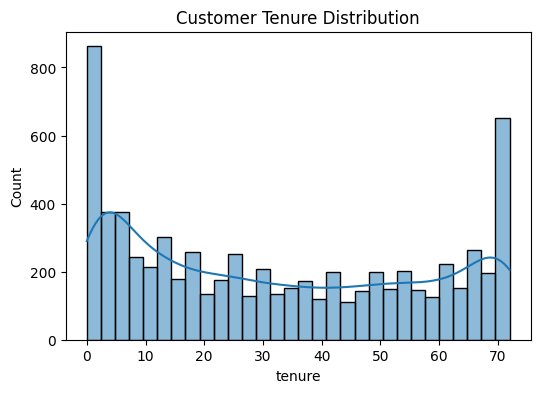

In [21]:
#Tenure Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Customer Tenure Distribution")
plt.show()

In [18]:
# ============================================================
# STEP 12: ONE HOT ENCODING (CATEGORICAL FEATURES)
# ============================================================
cat_cols = [
    "gender","Partner","Dependents","PhoneService","MultipleLines",
    "InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies","Contract",
    "PaperlessBilling","PaymentMethod"
]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [24]:
# ============================================================
# STEP 13: FINAL DATA CHECK
# ============================================================
print(df.head())
print(df.info())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa